# limTOD multiplicative radiometer noise + GLS / Hydra-lite

This notebook is intentionally self-contained and uses the real `limTOD` functions directly.

The order is fixed:

1. Run the original clean `limTOD` TOD path with no noise.
2. Build a matched `HPW_mapmaking` operator with the same beam normalisation/truncation as the TOD.
3. Run `TODSim.generate_TOD(..., white_noise_var=0)` and check it matches the direct `generate_TOD_sky` TOD.
4. Add multiplicative radiometer noise using `TODSim.generate_TOD` with `white_noise_var = 1/(Delta_nu * Delta_t)`.
5. Recover with stable heteroskedastic GLS using `noise_variance_t = white_noise_var * tod_clean_t**2`.
6. Optionally compare against a damped lightweight Hydra-style IRLS.

In [ ]:
# ============================================================
# CELL 1: imports and configuration
# ============================================================

from dataclasses import dataclass
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits

from limTOD.simulator import (
    TODSim,
    generate_TOD_sky,
    generate_LSTs_deg,
    generate_sky2sys_projection,
)
from limTOD.HPW_filter import HPW_mapmaking
from limTOD.sky_model import GDSM_sky_model


@dataclass
class SiteConfig:
    lat_deg: float = 53.2421
    lon_deg: float = -2.3067
    height_m: float = 100.0
    name: str = "Jodrell Bank"


@dataclass
class ObsConfig:
    freq_mhz: float = 70.0
    dt_seconds: float = 120.0
    start_time_utc: str = "2019-04-23 20:41:56.397"

    sim_nside: int = 32
    map_nside: int = 8

    azimuth_deg: float = 0.0
    elevation_deg: float = 90.0

    # Match the original working limTOD convention.
    # The pointed/truncated beam is normalised inside both TOD generation and matched operator generation.
    normalize_beam: bool = True

    # original clean-limTOD values for the sanity baseline.
    beam_truncate_frac: float = 0.05
    select_threshold: float = 0.05

    # Clean no-noise baseline settings.
    noise_variance_clean: float = 1.0
    regularization: float = 1e-4

    # Metrics: use adaptive hit cut, not a hard-coded weighted_hit > 1.
    hit_cut_fraction_of_median: float = 0.1

    reference_key: str = "fwhm10"


site = SiteConfig()
obs = ObsConfig()

HORN_DRY_DIR = Path("~/LimTOD/rhino-TODsim/data/HornDry").expanduser()
OUTDIR = Path("./hydra_lite_limtod_outputs_clean")
OUTDIR.mkdir(parents=True, exist_ok=True)

print(site)
print(obs)
print("Output directory:", OUTDIR.resolve())

SiteConfig(lat_deg=53.2421, lon_deg=-2.3067, height_m=100.0, name='Jodrell Bank')
ObsConfig(freq_mhz=70.0, dt_seconds=120.0, start_time_utc='2019-04-23 20:41:56.397', sim_nside=32, map_nside=8, azimuth_deg=0.0, elevation_deg=90.0, normalize_beam=True, beam_truncate_frac=0.05, select_threshold=0.05, noise_variance_clean=1.0, regularization=0.0001, hit_cut_fraction_of_median=0.1, reference_key='fwhm10')
Output directory: /Users/user/LimTOD/rhino-TODsim/RoastSim/hydra_lite_limtod_outputs_clean


In [2]:
# ============================================================
# CELL 2: small helper functions
# ============================================================

def as_finite_array(x, clip_negative=False):
    arr = np.nan_to_num(np.asarray(x, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    if clip_negative:
        arr = np.where(arr < 0.0, 0.0, arr)
    return arr


def print_percentiles(name, x, qs=(0, 1, 5, 50, 95, 99, 100)):
    x = np.asarray(x, dtype=float)
    vals = np.nanpercentile(x, qs)
    print(f"{name}:" + " / ".join([f"p{q}={v:.6g}" for q, v in zip(qs, vals)]))


def patch_to_full(patch, pix, nside, fill=hp.UNSEEN):
    full = np.full(hp.nside2npix(nside), fill, dtype=float)
    full[np.asarray(pix, dtype=int)] = np.asarray(patch, dtype=float).reshape(-1)
    return full


def full_to_patch(full_map, pix):
    return np.asarray(full_map, dtype=float).reshape(-1)[np.asarray(pix, dtype=int)]


def metric_summary(recovered, truth, weighted_hit=None, hit_cut=0.0):
    recovered = np.asarray(recovered, dtype=float).reshape(-1)
    truth = np.asarray(truth, dtype=float).reshape(-1)
    good = np.isfinite(recovered) & np.isfinite(truth)
    if weighted_hit is not None:
        wh = np.asarray(weighted_hit, dtype=float).reshape(-1)
        good &= np.isfinite(wh) & (wh > hit_cut)
    if good.sum() < 3:
        return dict(n_pix=int(good.sum()), rmse=np.nan, bias=np.nan, std=np.nan, corr=np.nan,
                    median_abs_residual=np.nan, p95_abs_residual=np.nan)
    res = recovered[good] - truth[good]
    return dict(
        n_pix=int(good.sum()),
        rmse=float(np.sqrt(np.mean(res**2))),
        bias=float(np.mean(res)),
        std=float(np.std(res)),
        corr=float(np.corrcoef(truth[good], recovered[good])[0, 1]),
        median_abs_residual=float(np.median(np.abs(res))),
        p95_abs_residual=float(np.percentile(np.abs(res), 95)),
    )


def compute_hitmap_from_operator(A):
    A = np.asarray(A, dtype=float)
    hits = np.sum(np.abs(A) > 0.0, axis=0)
    weighted_hits = np.sum(np.abs(A), axis=0)
    return hits, weighted_hits


def choose_adaptive_hit_cut(weighted_hits, fraction=0.1):
    wh = np.asarray(weighted_hits, dtype=float)
    good = np.isfinite(wh) & (wh > 0)
    if not np.any(good):
        return 0.0
    return float(fraction * np.nanmedian(wh[good]))


def find_beam_file(beam_dir, freq_mhz):
    beam_dir = Path(beam_dir).expanduser()
    if not beam_dir.exists():
        raise FileNotFoundError(f"Beam directory does not exist: {beam_dir}")
    fits_files = sorted(glob.glob(str(beam_dir / "*.fits"))) + sorted(glob.glob(str(beam_dir / "*.FITS")))
    if not fits_files:
        raise FileNotFoundError(f"No FITS files found in {beam_dir}")
    patterns = [f"{freq_mhz:.1f}", f"{freq_mhz:g}", str(int(round(freq_mhz)))]
    for pat in patterns:
        candidates = [f for f in fits_files if pat in Path(f).name]
        if candidates:
            chosen = Path(candidates[0])
            print("Chosen beam file:", chosen)
            return chosen
    chosen = Path(fits_files[0])
    print("WARNING: no exact frequency match; using first file:", chosen)
    return chosen


def load_healpix_beam_from_fits(path, target_nside=None):
    """Read a HEALPix beam FITS file and peak-normalise it, matching the original working notebook."""
    data = fits.getdata(path)
    data = np.asarray(data, dtype=float)
    if data.ndim == 1:
        beam = data
    elif data.ndim == 2:
        valid_rows = False
        valid_cols = False
        try:
            hp.npix2nside(data.shape[0]); valid_rows = True
        except Exception:
            pass
        try:
            hp.npix2nside(data.shape[1]); valid_cols = True
        except Exception:
            pass
        if valid_cols:
            beam = data[0]
        elif valid_rows:
            beam = data[:, 0]
        else:
            beam = data.reshape(-1)
    else:
        beam = data.reshape(-1)

    beam = as_finite_array(beam)
    beam = np.where(beam < 0.0, 0.0, beam)
    if np.nanmax(beam) <= 0:
        raise ValueError("Beam has non-positive/zero peak.")
    beam = beam / np.nanmax(beam)

    if target_nside is not None and hp.get_nside(beam) != target_nside:
        beam = hp.ud_grade(beam, nside_out=target_nside)
        beam = as_finite_array(beam)
        beam = np.where(beam < 0.0, 0.0, beam)
        beam = beam / np.nanmax(beam)
    return beam

In [3]:
# ============================================================
# CELL 3: load beam and sky/reference maps
# ============================================================

beam_file = find_beam_file(HORN_DRY_DIR, obs.freq_mhz)
real_beam = load_healpix_beam_from_fits(beam_file, target_nside=obs.sim_nside)

print("Beam NSIDE:", hp.get_nside(real_beam))
print("Beam min/median/max/sum:", np.nanmin(real_beam), np.nanmedian(real_beam), np.nanmax(real_beam), np.nansum(real_beam))
print("Beam convention: peak-normalised input; pointed/truncated beams are re-normalised per sample.")

# GDSM is treated as Galactic and rotated to Celestial/equatorial, matching limTOD pointing.
sky_gal = GDSM_sky_model(freq=obs.freq_mhz, nside=obs.sim_nside)
sky_gal = as_finite_array(sky_gal)
rot_gal_to_cel = hp.Rotator(coord=["G", "C"])
sky_nside32 = as_finite_array(rot_gal_to_cel.rotate_map_pixel(sky_gal))

print("Sky NSIDE:", hp.get_nside(sky_nside32))
print_percentiles("sky_nside32 [K]", sky_nside32)

reference_maps_full = {
    "plain": as_finite_array(hp.ud_grade(sky_nside32, nside_out=obs.map_nside)),
}
for fwhm in [10.0, 20.0, 40.0]:
    smoothed = hp.smoothing(sky_nside32, fwhm=np.radians(fwhm), verbose=False)
    reference_maps_full[f"fwhm{int(fwhm)}"] = as_finite_array(hp.ud_grade(smoothed, nside_out=obs.map_nside))

truth_full = reference_maps_full[obs.reference_key]
print("Reference maps:", list(reference_maps_full.keys()))
print_percentiles(f"truth_full {obs.reference_key} [K]", truth_full)

Chosen beam file: /Users/user/LimTOD/rhino-TODsim/data/HornDry/HornDry70.0.fits
Beam NSIDE: 32
Beam min/median/max/sum: 1.4426178898066612e-05 0.001310838363219467 1.0 462.2241887653284
Beam convention: peak-normalised input; pointed/truncated beams are re-normalised per sample.
Sky NSIDE: 32
sky_nside32 [K]:p0=-1220.8 / p1=1236.32 / p5=1385.27 / p50=2136.12 / p95=6172.02 / p99=12646.2 / p100=41439.4
Reference maps: ['plain', 'fwhm10', 'fwhm20', 'fwhm40']
truth_full fwhm10 [K]:p0=1231.51 / p1=1300.57 / p5=1416.15 / p50=2171.91 / p95=6317.41 / p99=10913.9 / p100=14885.2


/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_8924/1249300659.py:25: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  smoothed = hp.smoothing(sky_nside32, fwhm=np.radians(fwhm), verbose=False)


In [4]:
# ============================================================
# CELL 4: scan scenarios
# ============================================================

def make_base_24h_scan(obs, site):
    n = int(round(24.0 * 3600.0 / obs.dt_seconds))
    time_s = np.arange(n, dtype=float) * obs.dt_seconds
    lst = generate_LSTs_deg(site.lat_deg, site.lon_deg, site.height_m, time_s, start_time_utc=obs.start_time_utc)
    return dict(
        time_s=time_s,
        todsim_time_s=time_s.copy(),
        LST_deg=np.asarray(lst, dtype=float),
        az_deg=np.full(n, obs.azimuth_deg, dtype=float),
        el_deg=np.full(n, obs.elevation_deg, dtype=float),
        selfrot_deg=np.zeros(n, dtype=float),
        dt_seconds=obs.dt_seconds,
        n_days=1,
        clean_label="Base 24 h",
    )


def build_scan(obs, site, key):
    base = make_base_24h_scan(obs, site)
    n0 = len(base["time_s"])

    if key == "A_no_rotation_24h":
        scan = base.copy()
        scan["selfrot_deg"] = np.zeros(n0)
        scan["clean_label"] = "No rotation, 24 h"
        return scan

    if key == "B_slow_rotation_24h_one_turn_per_day":
        scan = base.copy()
        scan["selfrot_deg"] = (360.0 * base["time_s"] / (24.0 * 3600.0)) % 360.0
        scan["clean_label"] = "Slow rotation, 24 h"
        return scan

    if key == "C_fast_rotation_24h_one_turn_per_hour":
        scan = base.copy()
        scan["selfrot_deg"] = (360.0 * base["time_s"] / 3600.0) % 360.0
        scan["clean_label"] = "Fast rotation, 24 h"
        return scan

    if key == "E_same_LST_12days_30deg_step_stacked":
        n_days = 12
        LST = np.tile(base["LST_deg"], n_days)
        todsim_time = np.tile(base["todsim_time_s"], n_days)   # forces TODSim to repeat same LST sequence
        time_s = np.arange(n0 * n_days, dtype=float) * obs.dt_seconds
        day_index = np.repeat(np.arange(n_days), n0)
        selfrot = (30.0 * day_index) % 360.0
        return dict(
            time_s=time_s,
            todsim_time_s=todsim_time,
            LST_deg=LST,
            az_deg=np.full(n0 * n_days, obs.azimuth_deg),
            el_deg=np.full(n0 * n_days, obs.elevation_deg),
            selfrot_deg=selfrot,
            dt_seconds=obs.dt_seconds,
            n_days=n_days,
            clean_label="Same LST, 12 days, 30° step",
        )

    if key == "G_same_LST_12days_fast_hourly_stacked":
        n_days = 12
        LST = np.tile(base["LST_deg"], n_days)
        todsim_time = np.tile(base["todsim_time_s"], n_days)   # forces TODSim to repeat same LST sequence
        time_s = np.arange(n0 * n_days, dtype=float) * obs.dt_seconds
        selfrot = (360.0 * time_s / 3600.0) % 360.0
        return dict(
            time_s=time_s,
            todsim_time_s=todsim_time,
            LST_deg=LST,
            az_deg=np.full(n0 * n_days, obs.azimuth_deg),
            el_deg=np.full(n0 * n_days, obs.elevation_deg),
            selfrot_deg=selfrot,
            dt_seconds=obs.dt_seconds,
            n_days=n_days,
            clean_label="Same LST, 12 days, fast hourly",
        )

    raise KeyError(key)


SCENARIO_KEYS = [
    "A_no_rotation_24h",
    "C_fast_rotation_24h_one_turn_per_hour",
    "E_same_LST_12days_30deg_step_stacked",
    "G_same_LST_12days_fast_hourly_stacked",
]

scans = {key: build_scan(obs, site, key) for key in SCENARIO_KEYS}
for key, scan in scans.items():
    print(key, scan["clean_label"], "n_samples=", len(scan["LST_deg"]))

A_no_rotation_24h No rotation, 24 h n_samples= 720
C_fast_rotation_24h_one_turn_per_hour Fast rotation, 24 h n_samples= 720
E_same_LST_12days_30deg_step_stacked Same LST, 12 days, 30° step n_samples= 8640
G_same_LST_12days_fast_hourly_stacked Same LST, 12 days, fast hourly n_samples= 8640


In [6]:
# ============================================================
# CELL 5: matched limTOD mapper/operator and clean baseline runner
# ============================================================

def build_matched_mapper_and_operator(beam_map, scan):
    """Use HPW_mapmaking for pixel selection, then replace its operator with matched normalised operator."""
    mapper = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=scan["LST_deg"],
        lat_deg=site.lat_deg,
        azimuth_deg_list_group=scan["az_deg"],
        elevation_deg_list_group=scan["el_deg"],
        selfrot_deg_list_group=scan["selfrot_deg"],
        threshold=obs.select_threshold,
        nside_hires=obs.sim_nside,
        nside_target=obs.map_nside,
        beam_truncate_frac_thres=obs.beam_truncate_frac,
    )

    matched_A = generate_sky2sys_projection(
        beam_map=beam_map,
        LST_deg_list=scan["LST_deg"],
        lat_deg=site.lat_deg,
        azimuth_deg_list=scan["az_deg"],
        elevation_deg_list=scan["el_deg"],
        selfrot_deg_list=scan["selfrot_deg"],
        pixel_indices=mapper.pixel_indices,
        nside_hires=obs.sim_nside,
        nside_target=obs.map_nside,
        normalize_beam=obs.normalize_beam,
        truncate_frac_thres=obs.beam_truncate_frac,
    )

    mapper.Tsys_operators = np.asarray(matched_A, dtype=float)
    return mapper


def run_clean_baseline(case_key):
    scan = scans[case_key]
    print(" " + "="*90)
    print("CLEAN BASELINE:", case_key, "-", scan["clean_label"])
    print("="*90)

    tod_clean_direct = generate_TOD_sky(
        beam_map=real_beam,
        sky_map=sky_nside32,
        LST_deg_list=scan["LST_deg"],
        lat_deg=site.lat_deg,
        azimuth_deg_list=scan["az_deg"],
        elevation_deg_list=scan["el_deg"],
        selfrot_deg_list=scan["selfrot_deg"],
        nside_hires=obs.sim_nside,
        normalize_beam=obs.normalize_beam,
        truncate_frac_thres=obs.beam_truncate_frac,
    )
    tod_clean_direct = np.asarray(tod_clean_direct, dtype=float).reshape(-1)

    mapper = build_matched_mapper_and_operator(real_beam, scan)
    A = np.asarray(mapper.Tsys_operators, dtype=float)
    pix = np.asarray(mapper.pixel_indices, dtype=int)
    hits, weighted_hits = compute_hitmap_from_operator(A)
    hit_cut = choose_adaptive_hit_cut(weighted_hits, obs.hit_cut_fraction_of_median)

    truth_patch = full_to_patch(truth_full, pix)
    truth_plain = full_to_patch(reference_maps_full["plain"], pix)

    rec_clean, unc_clean = mapper(
        TOD_group=tod_clean_direct,
        dtime=scan["dt_seconds"],
        noise_variance=obs.noise_variance_clean,
        regularization=obs.regularization,
        use_high_pass=False,
    )
    rec_clean = np.asarray(rec_clean, dtype=float).reshape(-1)
    unc_clean = np.asarray(unc_clean, dtype=float).reshape(-1)

    metric_clean = metric_summary(rec_clean, truth_patch, weighted_hits, hit_cut=hit_cut)

    d_from_truth = A @ truth_patch

    print("A shape:", A.shape)
    print("n_pix:", len(pix))
    print("hit_cut:", hit_cut)
    print_percentiles("TOD clean direct", tod_clean_direct)
    print_percentiles("A row sums", A.sum(axis=1))
    print_percentiles("weighted hits", weighted_hits)
    print_percentiles("A @ truth_patch", d_from_truth)
    print("median TOD / median(A@truth):", np.nanmedian(tod_clean_direct) / np.nanmedian(d_from_truth))
    print("metric clean:", metric_clean)

    if metric_clean["n_pix"] == 0 or not np.isfinite(metric_clean["rmse"]):
        raise RuntimeError("Clean baseline invalid before noise.")
    if metric_clean["rmse"] > 10000:
        raise RuntimeError("Clean baseline RMSE enormous before noise. Stop here.")

    return dict(
        case_key=case_key,
        scan=scan,
        mapper=mapper,
        A=A,
        pix=pix,
        hits=hits,
        weighted_hits=weighted_hits,
        hit_cut=hit_cut,
        tod_clean_direct=tod_clean_direct,
        truth_patch=truth_patch,
        truth_plain=truth_plain,
        recovered_clean=rec_clean,
        unc_clean=unc_clean,
        metric_clean=metric_clean,
    )

In [7]:
# ============================================================
# CELL 6: run one clean case first
# ============================================================

TEST_CASE = "C_fast_rotation_24h_one_turn_per_hour"
base_case = run_clean_baseline(TEST_CASE)

CLEAN BASELINE: C_fast_rotation_24h_one_turn_per_hour - Fast rotation, 24 h


100%|██████████| 720/720 [00:00<00:00, 776.80it/s]



Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 720/720 [00:01<00:00, 651.72it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 720
Number of selected pixels: 336


100%|██████████| 720/720 [00:01<00:00, 652.15it/s]


Number of data points: 720
Number of selected pixels: 336


100%|██████████| 720/720 [00:01<00:00, 678.17it/s]

A shape: (720, 336)
n_pix: 336
hit_cut: 0.21188801475291325
TOD clean direct:p0=1639.55 / p1=1650.91 / p5=1666.29 / p50=2680.85 / p95=3546.77 / p99=3596.76 / p100=3622.5
A row sums:p0=1 / p1=1 / p5=1 / p50=1 / p95=1 / p99=1 / p100=1
weighted hits:p0=0.00183632 / p1=0.00192236 / p5=0.00640314 / p50=2.11888 / p95=4.88245 / p99=4.92467 / p100=4.95863
A @ truth_patch:p0=1648.11 / p1=1660.6 / p5=1676.34 / p50=2677.97 / p95=3504.91 / p99=3544.88 / p100=3582.85
median TOD / median(A@truth): 1.0010761457042605
metric clean: {'n_pix': 272, 'rmse': 605.5949913427412, 'bias': -80.99094819896486, 'std': 600.1547799103557, 'corr': 0.8095371902164034, 'median_abs_residual': 371.09953716499695, 'p95_abs_residual': 1154.4727177491504}


In [8]:
# ============================================================
# CELL 7: TODSim wrapper and zero-noise consistency check
# ============================================================

def beam_func_for_todsim(freq, nside):
    b = np.asarray(real_beam, dtype=float).copy()
    if hp.get_nside(b) != nside:
        b = hp.ud_grade(b, nside_out=nside)
        b = as_finite_array(b, clip_negative=True)
        b = b / np.nanmax(b)
    return b


def sky_func_for_todsim(freq, nside):
    s = np.asarray(sky_nside32, dtype=float).copy()
    if hp.get_nside(s) != nside:
        s = hp.ud_grade(s, nside_out=nside)
        s = as_finite_array(s)
    return s


limtod_sim = TODSim(
    ant_latitude_deg=site.lat_deg,
    ant_longitude_deg=site.lon_deg,
    ant_height_m=site.height_m,
    beam_func=beam_func_for_todsim,
    sky_func=sky_func_for_todsim,
    beam_nside=obs.sim_nside,
    sky_nside=obs.sim_nside,
)


def run_todsim_generate_TOD(scan, white_noise_var, seed=0):
    """Use limTOD TODSim.generate_TOD; white_noise_var is fractional variance."""
    np.random.seed(seed)
    overall_TOD, sky_TOD, gain_noise_TOD, LST_from_todsim = limtod_sim.generate_TOD(
        freq_list=[obs.freq_mhz],
        time_list=scan["todsim_time_s"],
        azimuth_deg_list=scan["az_deg"],
        elevation_deg=scan["el_deg"],
        selfrot_deg_list=scan["selfrot_deg"],
        start_time_utc=obs.start_time_utc,
        Tsys_others_TOD=None,
        background_gain_TOD=None,
        gain_noise_TOD=None,
        gain_noise_params=None,
        white_noise_var=white_noise_var,
        return_LSTs=True,
        nside_hires=obs.sim_nside,
        normalize_beam=obs.normalize_beam,
        truncate_frac_thres=obs.beam_truncate_frac,
    )
    return dict(
        tod_noisy=np.asarray(overall_TOD[0], dtype=float).reshape(-1),
        tod_clean=np.asarray(sky_TOD[0], dtype=float).reshape(-1),
        gain_noise_TOD=gain_noise_TOD,
        LST_from_todsim=np.asarray(LST_from_todsim, dtype=float).reshape(-1),
        white_noise_var=float(white_noise_var),
        sigma_frac=float(np.sqrt(white_noise_var)),
    )


sim_zero = run_todsim_generate_TOD(base_case["scan"], white_noise_var=0.0, seed=0)

diff = sim_zero["tod_clean"] - base_case["tod_clean_direct"]
rel_med = np.nanmedian(np.abs(diff)) / max(np.nanmedian(np.abs(base_case["tod_clean_direct"])), 1e-30)

print_percentiles("direct clean TOD", base_case["tod_clean_direct"])
print_percentiles("TODSim clean TOD", sim_zero["tod_clean"])
print_percentiles("TODSim-direct difference", diff)
print("relative median abs difference:", rel_med)

if rel_med > 1e-6:
    raise RuntimeError("TODSim white_noise_var=0 does not match direct generate_TOD_sky. Stop before adding noise.")

100%|██████████| 720/720 [00:00<00:00, 724.41it/s]

direct clean TOD:p0=1639.55 / p1=1650.91 / p5=1666.29 / p50=2680.85 / p95=3546.77 / p99=3596.76 / p100=3622.5
TODSim clean TOD:p0=1639.55 / p1=1650.91 / p5=1666.29 / p50=2680.85 / p95=3546.77 / p99=3596.76 / p100=3622.5
TODSim-direct difference:p0=0 / p1=0 / p5=0 / p50=0 / p95=0 / p99=0 / p100=0
relative median abs difference: 0.0


In [9]:
# ============================================================
# CELL 8: multiplicative radiometer noise and stable GLS
# ============================================================

def white_noise_var_from_radiometer(delta_nu_hz, dt_seconds):
    return 1.0 / (float(delta_nu_hz) * float(dt_seconds))


def multiplicative_variance_t(tod_clean, white_noise_var):
    tod_clean = np.asarray(tod_clean, dtype=float).reshape(-1)
    if white_noise_var <= 0:
        return np.ones_like(tod_clean)
    var_t = float(white_noise_var) * tod_clean**2
    good = np.isfinite(var_t) & (var_t > 0)
    floor = 1e-8 * np.nanmedian(var_t[good])
    floor = max(floor, 1e-30)
    return np.maximum(var_t, floor)


def recover_with_limtod_gls(case, tod_noisy, tod_clean_for_variance, white_noise_var):
    var_t = multiplicative_variance_t(tod_clean_for_variance, white_noise_var)
    rec, unc = case["mapper"](
        TOD_group=np.asarray(tod_noisy, dtype=float),
        dtime=case["scan"]["dt_seconds"],
        noise_variance=var_t,
        regularization=obs.regularization,
        use_high_pass=False,
    )
    rec = np.asarray(rec, dtype=float).reshape(-1)
    unc = np.asarray(unc, dtype=float).reshape(-1)
    metric = metric_summary(rec, case["truth_patch"], case["weighted_hits"], hit_cut=case["hit_cut"])
    return rec, unc, var_t, metric


NOISE_CASES = {
    "none": None,
    "raw_10MHz_over_8192": 10e6 / 8192,
    "bandavg_100kHz": 1e5,
    "bandavg_1MHz": 1e6,
}

single_noise_results = {}
rows = []

for noise_name, delta_nu in NOISE_CASES.items():
    if delta_nu is None:
        wnv = 0.0
    else:
        wnv = white_noise_var_from_radiometer(delta_nu, base_case["scan"]["dt_seconds"])

    sim = run_todsim_generate_TOD(base_case["scan"], white_noise_var=wnv, seed=0)
    rec, unc, var_t, metric = recover_with_limtod_gls(
        base_case,
        tod_noisy=sim["tod_noisy"],
        tod_clean_for_variance=sim["tod_clean"],
        white_noise_var=sim["white_noise_var"],
    )

    equiv_sigma_K_med = 0.0 if wnv == 0 else float(np.nanmedian(np.sqrt(var_t)))
    row = dict(
        case_key=base_case["case_key"],
        noise_case=noise_name,
        delta_nu_Hz=np.nan if delta_nu is None else float(delta_nu),
        white_noise_var=sim["white_noise_var"],
        sigma_frac=sim["sigma_frac"],
        equiv_sigma_K_median=equiv_sigma_K_med,
        **metric,
    )
    rows.append(row)
    single_noise_results[noise_name] = dict(sim=sim, rec=rec, unc=unc, var_t=var_t, metric=metric)

single_noise_df = pd.DataFrame(rows)
display(single_noise_df)

# The raw-channel result should not explode if the clean baseline is consistent.
raw_m = single_noise_results["raw_10MHz_over_8192"]["metric"]
if raw_m["n_pix"] == 0 or not np.isfinite(raw_m["rmse"]):
    raise RuntimeError("Raw-channel multiplicative GLS produced invalid metric.")

100%|██████████| 720/720 [00:01<00:00, 515.43it/s]


,case_key,noise_case,delta_nu_Hz,white_noise_var,sigma_frac,equiv_sigma_K_median,n_pix,rmse,bias,std,corr,median_abs_residual,p95_abs_residual
0,C_fast_rotation_24h_one_turn_per_hour,none,NaN,0.000000e+00,0.000000,0.000000,272,605.594991,-80.990948,600.154780,0.809537,371.099537,1154.472718
1,C_fast_rotation_24h_one_turn_per_hour,raw_10MHz_over_8192,1220.703125,6.826667e-06,0.002613,7.004496,272,1142.271575,-487.459585,1033.037998,0.565701,587.790486,2329.494023
2,C_fast_rotation_24h_one_turn_per_hour,bandavg_100kHz,100000.000000,8.333333e-08,0.000289,0.773895,272,548.643394,-51.555988,546.215666,0.838296,323.044397,1094.175215
3,C_fast_rotation_24h_one_turn_per_hour,bandavg_1MHz,1000000.000000,8.333333e-09,0.000091,0.244727,272,616.440465,-13.374797,616.295353,0.812694,339.924201,1270.583741


100%|██████████| 720/720 [00:02<00:00, 346.06it/s]


TOD comparison for: C_fast_rotation_24h_one_turn_per_hour
Noise case: raw_10MHz_over_8192

Direct clean median: 2680.85028646736
TODSim zero-noise median: 2680.85028646736
Noisy TOD median: 2677.384059214925

TODSim zero - direct:
  median abs: 0.0
  max abs: 0.0
  relative median abs: 0.0

Noisy - clean:
  median abs: 4.298362643569931
  std: 7.027058782459384
  expected median sigma K: 7.004496297215087
  sigma_frac: 0.0026127890589687235
  white_noise_var: 6.826666666666667e-06


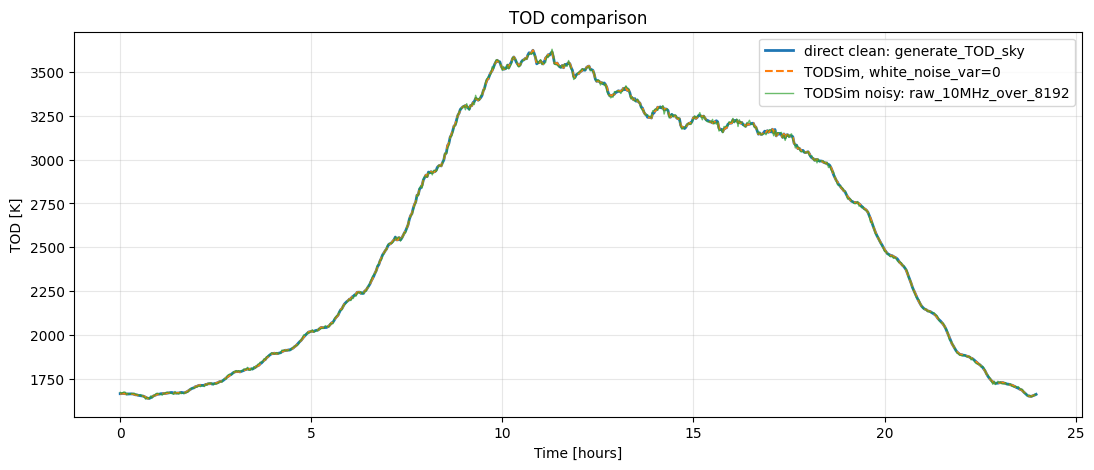

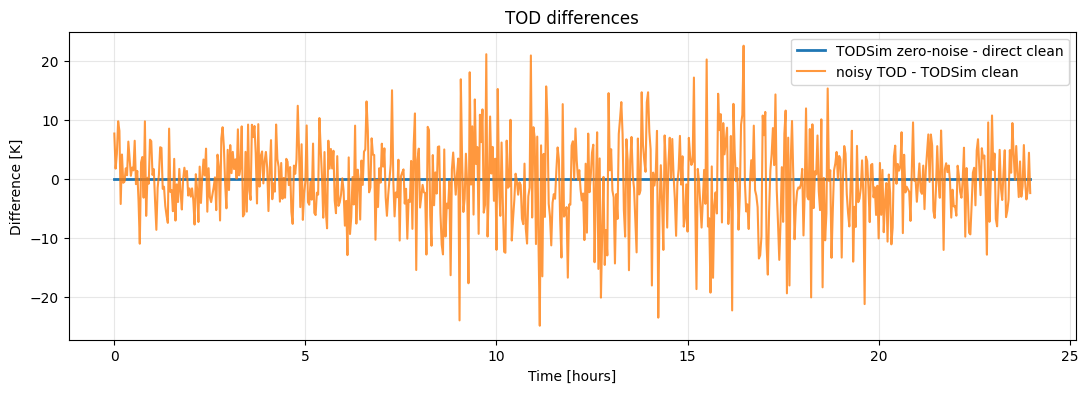

In [14]:
# ============================================================
# CELL 8B: compare direct clean TOD, TODSim zero-noise, and noisy TOD
# ============================================================

def plot_tod_comparison(case, noise_name="raw_10MHz_over_8192", n_plot=720):
    """
    Compare:
      1. direct clean TOD from generate_TOD_sky
      2. TODSim clean TOD with white_noise_var=0
      3. TODSim noisy TOD with multiplicative radiometer noise
    """

    # direct clean TOD
    tod_direct = np.asarray(case["tod_clean_direct"], dtype=float).reshape(-1)

    # TODSim zero-noise TOD
    sim_zero = run_todsim_generate_TOD(
        case["scan"],
        white_noise_var=0.0,
        seed=0,
    )
    tod_todsim_zero = np.asarray(sim_zero["tod_clean"], dtype=float).reshape(-1)

    # TODSim noisy TOD
    sim_noisy = single_noise_results[noise_name]["sim"]
    tod_noisy = np.asarray(sim_noisy["tod_noisy"], dtype=float).reshape(-1)
    tod_noisy_clean_part = np.asarray(sim_noisy["tod_clean"], dtype=float).reshape(-1)

    n = min(n_plot, len(tod_direct))
    t_hr = case["scan"]["time_s"][:n] / 3600.0

    diff_zero = tod_todsim_zero - tod_direct
    diff_noisy = tod_noisy - tod_noisy_clean_part

    print("TOD comparison for:", case["case_key"])
    print("Noise case:", noise_name)
    print()
    print("Direct clean median:", np.nanmedian(tod_direct))
    print("TODSim zero-noise median:", np.nanmedian(tod_todsim_zero))
    print("Noisy TOD median:", np.nanmedian(tod_noisy))
    print()
    print("TODSim zero - direct:")
    print("  median abs:", np.nanmedian(np.abs(diff_zero)))
    print("  max abs:", np.nanmax(np.abs(diff_zero)))
    print("  relative median abs:", np.nanmedian(np.abs(diff_zero)) / max(np.nanmedian(np.abs(tod_direct)), 1e-30))
    print()
    print("Noisy - clean:")
    print("  median abs:", np.nanmedian(np.abs(diff_noisy)))
    print("  std:", np.nanstd(diff_noisy))
    print("  expected median sigma K:", np.nanmedian(np.abs(tod_noisy_clean_part) * sim_noisy["sigma_frac"]))
    print("  sigma_frac:", sim_noisy["sigma_frac"])
    print("  white_noise_var:", sim_noisy["white_noise_var"])

    plt.figure(figsize=(13, 5))
    plt.plot(t_hr, tod_direct[:n], label="direct clean: generate_TOD_sky", linewidth=2)
    plt.plot(t_hr, tod_todsim_zero[:n], "--", label="TODSim, white_noise_var=0", linewidth=1.5)
    plt.plot(t_hr, tod_noisy[:n], alpha=0.7, label=f"TODSim noisy: {noise_name}", linewidth=1)
    plt.xlabel("Time [hours]")
    plt.ylabel("TOD [K]")
    plt.title("TOD comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.plot(t_hr, diff_zero[:n], label="TODSim zero-noise - direct clean", linewidth=2)
    plt.plot(t_hr, diff_noisy[:n], label="noisy TOD - TODSim clean", alpha=0.8)
    plt.xlabel("Time [hours]")
    plt.ylabel("Difference [K]")
    plt.title("TOD differences")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "tod_direct": tod_direct,
        "tod_todsim_zero": tod_todsim_zero,
        "tod_noisy": tod_noisy,
        "diff_zero": diff_zero,
        "diff_noisy": diff_noisy,
        "sim_zero": sim_zero,
        "sim_noisy": sim_noisy,
    }


tod_compare = plot_tod_comparison(
    base_case,
    noise_name="raw_10MHz_over_8192",
    n_plot=720,
)

100%|██████████| 720/720 [00:02<00:00, 315.26it/s]


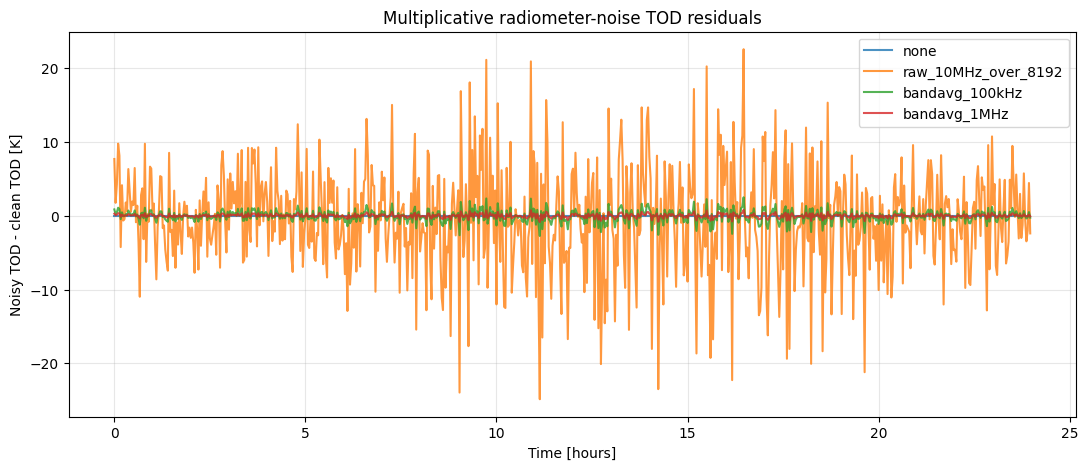

Zero-noise consistency:
  median abs: 0.0
  max abs: 0.0
  relative median abs: 0.0


In [16]:
# ============================================================
# CELL 8C: plot TOD differences for all noise cases
# ============================================================

def plot_all_noise_tod_differences(case, n_plot=720):
    tod_direct = np.asarray(case["tod_clean_direct"], dtype=float).reshape(-1)

    sim_zero = run_todsim_generate_TOD(case["scan"], white_noise_var=0.0, seed=0)
    tod_zero = np.asarray(sim_zero["tod_clean"], dtype=float).reshape(-1)

    n = min(n_plot, len(tod_direct))
    t_hr = case["scan"]["time_s"][:n] / 3600.0

    plt.figure(figsize=(13, 5))

    for noise_name, pack in single_noise_results.items():
        sim = pack["sim"]
        tod_noisy = np.asarray(sim["tod_noisy"], dtype=float).reshape(-1)
        tod_clean = np.asarray(sim["tod_clean"], dtype=float).reshape(-1)

        diff = tod_noisy - tod_clean
        plt.plot(t_hr, diff[:n], label=noise_name, alpha=0.8)

    plt.xlabel("Time [hours]")
    plt.ylabel("Noisy TOD - clean TOD [K]")
    plt.title("Multiplicative radiometer-noise TOD residuals")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print("Zero-noise consistency:")
    dz = tod_zero - tod_direct
    print("  median abs:", np.nanmedian(np.abs(dz)))
    print("  max abs:", np.nanmax(np.abs(dz)))
    print("  relative median abs:", np.nanmedian(np.abs(dz)) / max(np.nanmedian(np.abs(tod_direct)), 1e-30))


plot_all_noise_tod_differences(base_case, n_plot=720)

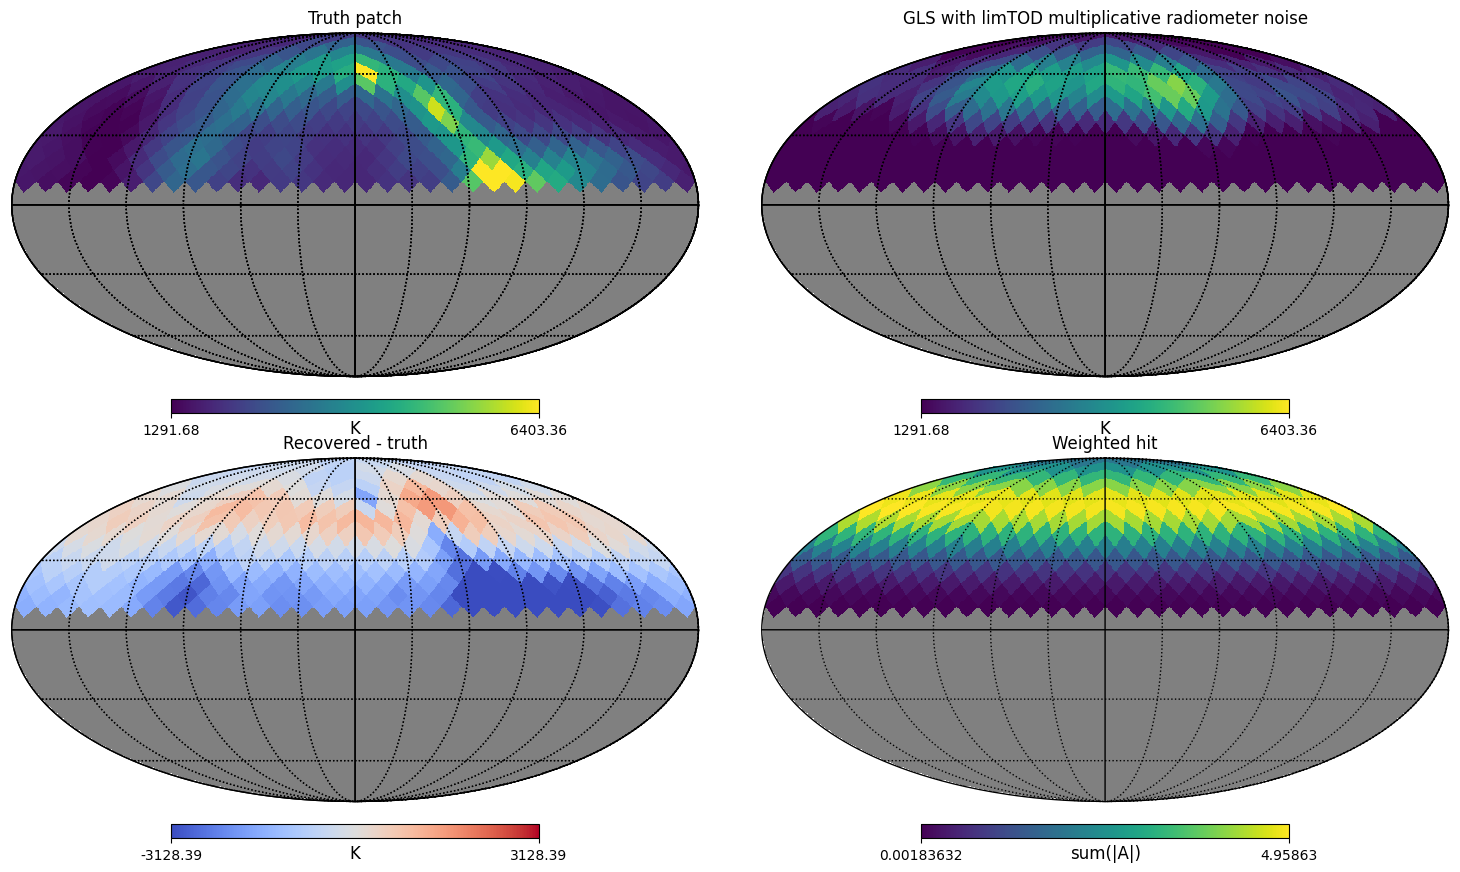

In [10]:
# ============================================================
# CELL 9: plot one single-case result
# ============================================================

def plot_result_case(case, rec, title):
    truth = case["truth_patch"]
    pix = case["pix"]
    wh = case["weighted_hits"]
    residual = np.asarray(rec) - truth
    vmin, vmax = np.nanpercentile(truth, [1, 99])
    rmax = np.nanpercentile(np.abs(residual), 95)
    plt.figure(figsize=(15, 8.5))
    hp.mollview(patch_to_full(truth, pix, obs.map_nside), title="Truth patch", unit="K", min=vmin, max=vmax, sub=(2,2,1), badcolor="gray"); hp.graticule()
    hp.mollview(patch_to_full(rec, pix, obs.map_nside), title=title, unit="K", min=vmin, max=vmax, sub=(2,2,2), badcolor="gray"); hp.graticule()
    hp.mollview(patch_to_full(residual, pix, obs.map_nside), title="Recovered - truth", unit="K", min=-rmax, max=rmax, cmap="coolwarm", sub=(2,2,3), badcolor="gray"); hp.graticule()
    hp.mollview(patch_to_full(wh, pix, obs.map_nside), title="Weighted hit", unit="sum(|A|)", sub=(2,2,4), badcolor="gray"); hp.graticule()
    plt.show()

plot_result_case(base_case, single_noise_results["raw_10MHz_over_8192"]["rec"], "GLS with limTOD multiplicative radiometer noise")

In [ ]:
# ============================================================
# CELL 10: optional damped Hydra-lite IRLS for one case
# ============================================================

# It follows Hydra's multiplicative idea: Var[d_t | p] = white_noise_var * (A p)_t^2.

def direct_gls_known_variance(A, d, var_t, regularization):
    A = np.asarray(A, dtype=float)
    d = np.asarray(d, dtype=float).reshape(-1)
    var_t = np.asarray(var_t, dtype=float).reshape(-1)
    good = np.isfinite(var_t) & (var_t > 0)
    floor = 1e-8 * np.nanmedian(var_t[good])
    floor = max(floor, 1e-30)
    var_t = np.maximum(var_t, floor)
    w = 1.0 / var_t
    lhs = A.T @ (A * w[:, None]) + regularization * np.eye(A.shape[1])
    rhs = A.T @ (w * d)
    rec = np.linalg.solve(lhs, rhs)
    try:
        cov = np.linalg.inv(lhs)
        unc = np.sqrt(np.clip(np.diag(cov), 0, np.inf))
    except Exception:
        unc = np.full(A.shape[1], np.nan)
    return rec, unc


def hydra_lite_damped_irls(case, d_noisy, white_noise_var, p_init, damping=0.3, max_iter=20, tol=1e-6, model_floor_frac=1e-3):
    A = case["A"]
    p = np.asarray(p_init, dtype=float).reshape(-1).copy()
    d_noisy = np.asarray(d_noisy, dtype=float).reshape(-1)
    model_floor = max(model_floor_frac * np.nanmedian(np.abs(d_noisy)), 1e-30)
    history = []
    for it in range(1, max_iter + 1):
        model = A @ p
        sign = np.where(model >= 0, 1.0, -1.0)
        model_safe = sign * np.maximum(np.abs(model), model_floor)
        var_t = multiplicative_variance_t(model_safe, white_noise_var)
        p_raw, _ = direct_gls_known_variance(A, d_noisy, var_t, obs.regularization)
        p_new = (1.0 - damping) * p + damping * p_raw
        step = np.linalg.norm(p_new - p) / max(np.linalg.norm(p), 1e-30)
        history.append(step)
        print(f"iter {it:02d}: step={step:.3e}")
        p = p_new
        if step < tol:
            break
    model = A @ p
    var_final = multiplicative_variance_t(model, white_noise_var)
    rec_final, unc_final = direct_gls_known_variance(A, d_noisy, var_final, obs.regularization)
    metric = metric_summary(rec_final, case["truth_patch"], case["weighted_hits"], hit_cut=case["hit_cut"])
    return rec_final, unc_final, dict(n_iter=it, last_step=history[-1], history=history, metric=metric)

raw_pack = single_noise_results["raw_10MHz_over_8192"]
rec_hydra, unc_hydra, info_hydra = hydra_lite_damped_irls(
    base_case,
    d_noisy=raw_pack["sim"]["tod_noisy"],
    white_noise_var=raw_pack["sim"]["white_noise_var"],
    p_init=raw_pack["rec"],
    damping=0.3,
    max_iter=20,
)

print("Hydra-lite metric:", info_hydra["metric"])

iter 01: step=3.469e-04
iter 02: step=2.423e-04
iter 03: step=1.692e-04
iter 04: step=1.182e-04
iter 05: step=8.262e-05
iter 06: step=5.775e-05
iter 07: step=4.037e-05
iter 08: step=2.823e-05
iter 09: step=1.975e-05
iter 10: step=1.381e-05
iter 11: step=9.665e-06
iter 12: step=6.765e-06
iter 13: step=4.735e-06
iter 14: step=3.316e-06
iter 15: step=2.322e-06
iter 16: step=1.627e-06
iter 17: step=1.140e-06
iter 18: step=7.986e-07
Hydra-lite metric: {'n_pix': 272, 'rmse': 1142.066980054203, 'bias': -487.0568737605093, 'std': 1033.001737003751, 'corr': 0.5658413962883269, 'median_abs_residual': 588.1868213973024, 'p95_abs_residual': 2329.8232631034984}


In [12]:
# ============================================================
# CELL 11: full A/C/E/G scenario sweep with stable GLS
# ============================================================

all_cases = {}
all_rows = []

for key in SCENARIO_KEYS:
    case = run_clean_baseline(key)
    all_cases[key] = case

    # zero-noise TODSim check for this scan
    sim_zero = run_todsim_generate_TOD(case["scan"], white_noise_var=0.0, seed=0)
    diff = sim_zero["tod_clean"] - case["tod_clean_direct"]
    rel_med = np.nanmedian(np.abs(diff)) / max(np.nanmedian(np.abs(case["tod_clean_direct"])), 1e-30)
    if rel_med > 1e-6:
        raise RuntimeError(f"TODSim zero-noise mismatch for {key}: {rel_med}")

    for noise_name, delta_nu in NOISE_CASES.items():
        wnv = 0.0 if delta_nu is None else white_noise_var_from_radiometer(delta_nu, case["scan"]["dt_seconds"])
        sim = run_todsim_generate_TOD(case["scan"], white_noise_var=wnv, seed=0)
        rec, unc, var_t, metric = recover_with_limtod_gls(case, sim["tod_noisy"], sim["tod_clean"], sim["white_noise_var"])
        all_rows.append(dict(
            case_key=key,
            clean_label=case["scan"]["clean_label"],
            noise_case=noise_name,
            delta_nu_Hz=np.nan if delta_nu is None else float(delta_nu),
            white_noise_var=sim["white_noise_var"],
            sigma_frac=sim["sigma_frac"],
            equiv_sigma_K_median=0.0 if wnv == 0 else float(np.nanmedian(np.sqrt(var_t))),
            **metric,
        ))

scenario_noise_df = pd.DataFrame(all_rows)
display(scenario_noise_df)
scenario_noise_df.to_csv(OUTDIR / "scenario_multiplicative_radiometer_gls_summary.csv", index=False)
print("Saved:", OUTDIR / "scenario_multiplicative_radiometer_gls_summary.csv")

CLEAN BASELINE: A_no_rotation_24h - No rotation, 24 h


100%|██████████| 720/720 [00:01<00:00, 666.52it/s]



Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 720/720 [00:01<00:00, 472.21it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 720
Number of selected pixels: 304


...

100%|██████████| 8640/8640 [00:13<00:00, 649.72it/s]


A shape: (8640, 336)
n_pix: 336
hit_cut: 2.5426561770349516
TOD clean direct:p0=1639.55 / p1=1650.62 / p5=1666.29 / p50=2680.85 / p95=3546.77 / p99=3597.16 / p100=3622.5
A row sums:p0=1 / p1=1 / p5=1 / p50=1 / p95=1 / p99=1 / p100=1
weighted hits:p0=0.0220359 / p1=0.0230684 / p5=0.0768377 / p50=25.4266 / p95=58.5894 / p99=59.096 / p100=59.5036
A @ truth_patch:p0=1648.11 / p1=1660.56 / p5=1676.34 / p50=2677.97 / p95=3504.91 / p99=3545.04 / p100=3582.85
median TOD / median(A@truth): 1.0010761457042605
metric clean: {'n_pix': 272, 'rmse': 651.8272234645312, 'bias': -17.46347387039727, 'std': 651.5932445397649, 'corr': 0.795020746111037, 'median_abs_residual': 383.6867519882046, 'p95_abs_residual': 1354.6095028279817}


100%|██████████| 8640/8640 [00:14<00:00, 591.01it/s]


,case_key,clean_label,noise_case,delta_nu_Hz,white_noise_var,sigma_frac,equiv_sigma_K_median,n_pix,rmse,bias,std,corr,median_abs_residual,p95_abs_residual
0,A_no_rotation_24h,"No rotation, 24 h",none,NaN,0.000000e+00,0.000000,0.000000,272,1160.247192,-344.109550,1108.044297,0.510276,669.899643,2504.369440
1,A_no_rotation_24h,"No rotation, 24 h",raw_10MHz_over_8192,1220.703125,6.826667e-06,0.002613,6.983750,272,1289.592190,-576.693522,1153.461138,0.516048,705.307642,2660.777116
2,A_no_rotation_24h,"No rotation, 24 h",bandavg_100kHz,100000.000000,8.333333e-08,0.000289,0.771603,272,1137.407067,-314.730100,1092.995791,0.512208,672.898794,2432.050848
3,A_no_rotation_24h,"No rotation, 24 h",bandavg_1MHz,1000000.000000,8.333333e-09,0.000091,0.244002,272,1065.361072,-132.849447,1057.045523,0.510255,651.133467,2256.617142
4,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",none,NaN,0.000000e+00,0.000000,0.000000,272,605.594991,-80.990948,600.154780,0.809537,371.099537,1154.472718
5,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",raw_10MHz_over_8192,1220.703125,6.826667e-06,0.002613,7.004496,272,1142.271575,-487.459585,1033.037998,0.565701,587.790486,2329.494023
6,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",bandavg_100kHz,100000.000000,8.333333e-08,0.000289,0.773895,272,548.643394,-51.555988,546.215666,0.838296,323.044397,1094.175215
7,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",bandavg_1MHz,1000000.000000,8.333333e-09,0.000091,0.244727,272,616.440465,-13.374797,616.295353,0.812694,339.924201,1270.583741
8,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",none,NaN,0.000000e+00,0.000000,0.000000,272,461.903470,7.884168,461.836178,0.875403,268.100551,947.700452
9,E_same_LST_12days_30deg_step_stacked,"Same LST, 12 days, 30° step",raw_10MHz_over_8192,1220.703125,6.826667e-06,0.002613,6.975709,272,703.064128,-222.548923,666.911648,0.756397,278.625062,1557.404764


Saved: hydra_lite_limtod_outputs_clean/scenario_multiplicative_radiometer_gls_summary.csv


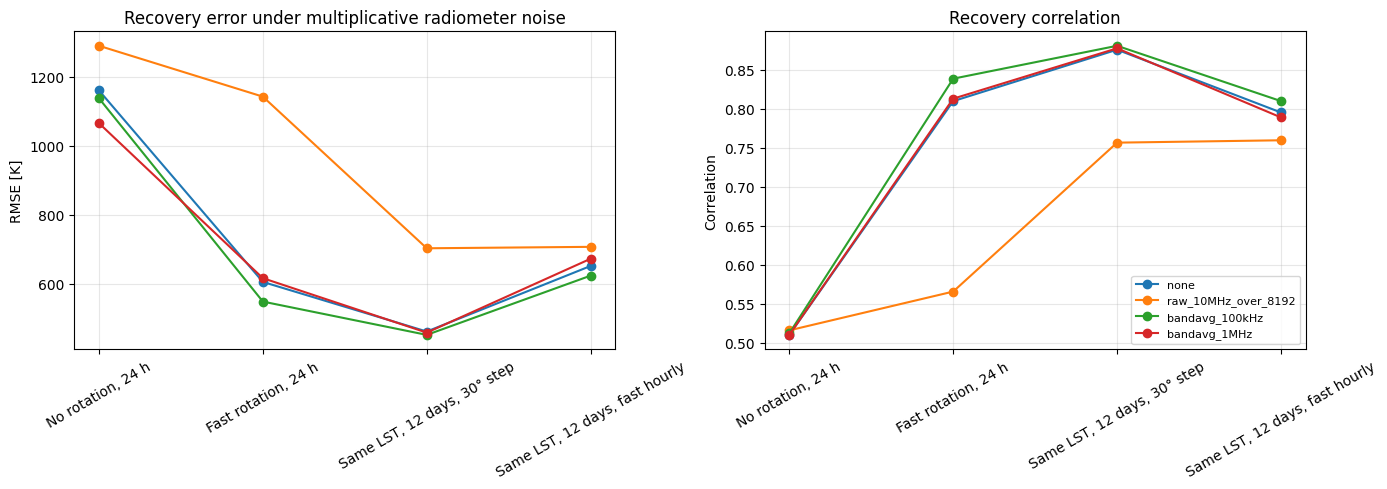

In [13]:
# ============================================================
# CELL 12: summary plots
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for noise_case in scenario_noise_df["noise_case"].unique():
    sub = scenario_noise_df[scenario_noise_df["noise_case"] == noise_case]
    ax[0].plot(sub["clean_label"], sub["rmse"], marker="o", label=noise_case)
    ax[1].plot(sub["clean_label"], sub["corr"], marker="o", label=noise_case)

ax[0].set_ylabel("RMSE [K]")
ax[0].set_title("Recovery error under multiplicative radiometer noise")
ax[1].set_ylabel("Correlation")
ax[1].set_title("Recovery correlation")
for a in ax:
    a.tick_params(axis="x", rotation=30)
    a.grid(alpha=0.3)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Making Recovery Better

In [18]:
# ============================================================
# CELL A: choose recovery result to diagnose, robust key finder
# ============================================================

DIAG_CASE = base_case
DIAG_NOISE_NAME = "bandavg_100kHz"   # change if needed

def show_dict_tree(d, prefix="", max_depth=2, depth=0):
    if not isinstance(d, dict) or depth > max_depth:
        return
    for k, v in d.items():
        if isinstance(v, dict):
            print(f"{prefix}{k}/")
            show_dict_tree(v, prefix + "  ", max_depth=max_depth, depth=depth+1)
        else:
            shape = getattr(v, "shape", None)
            if shape is None and hasattr(v, "__len__") and not isinstance(v, str):
                try:
                    shape = f"len={len(v)}"
                except Exception:
                    shape = ""
            print(f"{prefix}{k}: {type(v).__name__}, {shape}")

def find_first_array_by_keys(d, candidate_keys):
    """
    Recursively search nested dictionaries for the first matching key.
    """
    if not isinstance(d, dict):
        return None, None

    for key in candidate_keys:
        if key in d:
            return d[key], key

    for k, v in d.items():
        if isinstance(v, dict):
            found, found_key = find_first_array_by_keys(v, candidate_keys)
            if found is not None:
                return found, f"{k}/{found_key}"

    return None, None

if "single_noise_results" not in globals():
    raise RuntimeError("single_noise_results does not exist yet. Run the noisy recovery cells first.")

if DIAG_NOISE_NAME not in single_noise_results:
    print("Available noise names:")
    print(list(single_noise_results.keys()))
    raise RuntimeError(f"{DIAG_NOISE_NAME} not found in single_noise_results.")

diag_pack = single_noise_results[DIAG_NOISE_NAME]

print("Structure of single_noise_results[DIAG_NOISE_NAME]:")
show_dict_tree(diag_pack, max_depth=3)

rec, rec_key = find_first_array_by_keys(
    diag_pack,
    [
        "rec_gls",
        "recovered_gls",
        "recovered",
        "rec",
        "map_gls",
        "sky_gls",
        "sky_estimation",
        "sky_map",
    ],
)

unc, unc_key = find_first_array_by_keys(
    diag_pack,
    [
        "unc_gls",
        "uncertainty_gls",
        "uncertainty",
        "unc",
        "sky_uncertainty",
    ],
)

if rec is None:
    raise RuntimeError(
        "Could not find recovered map in diag_pack. Look at printed structure above and tell me the key name."
    )

rec = np.asarray(rec, dtype=float).reshape(-1)

if unc is None:
    print("No uncertainty map found; filling with NaNs.")
    unc = np.full_like(rec, np.nan)
else:
    unc = np.asarray(unc, dtype=float).reshape(-1)

print("\nUsing recovered map key:", rec_key)
print("Using uncertainty key:", unc_key)

truth = np.asarray(DIAG_CASE["truth_patch"], dtype=float).reshape(-1)
pix = np.asarray(DIAG_CASE["pix"], dtype=int)
weighted_hits = np.asarray(DIAG_CASE["weighted_hits"], dtype=float).reshape(-1)

resid = rec - truth

print("\nDiagnostics:")
print("n pixels:", len(pix))
print("truth shape:", truth.shape)
print("rec shape:", rec.shape)
print("weighted_hits shape:", weighted_hits.shape)
print("truth range:", np.nanmin(truth), np.nanmax(truth))
print("recovered range:", np.nanmin(rec), np.nanmax(rec))
print("residual range:", np.nanmin(resid), np.nanmax(resid))
print("weighted hit percentiles:", np.nanpercentile(weighted_hits, [0, 1, 5, 25, 50, 75, 95, 99, 100]))

Structure of single_noise_results[DIAG_NOISE_NAME]:
sim/
  tod_noisy: ndarray, (720,)
  tod_clean: ndarray, (720,)
  gain_noise_TOD: float, None
  LST_from_todsim: ndarray, (720,)
  white_noise_var: float, None
  sigma_frac: float, None
rec: ndarray, (336,)
unc: ndarray, (336,)
var_t: ndarray, (720,)
metric/
  n_pix: int, None
  rmse: float, None
  bias: float, None
  std: float, None
  corr: float, None
  median_abs_residual: float, None
  p95_abs_residual: float, None

Using recovered map key: rec
Using uncertainty key: unc

Diagnostics:
n pixels: 336
truth shape: (336,)
rec shape: (336,)
weighted_hits shape: (336,)
truth range: 1231.508522804028 8845.820112847348
recovered range: -525.9067568120323 6531.937505953354
residual range: -7521.8109805691165 1360.2944991290988
weighted hit percentiles: [1.83632315e-03 1.92236276e-03 6.40314058e-03 3.65000712e-01
 2.11888015e+00 4.06915736e+00 4.88245037e+00 4.92466871e+00
 4.95863282e+00]


,n_pix,rmse,mae,bias,corr,hit_cut_fraction_of_median,hit_cut
0,336,1125.398291,670.080576,-367.446641,0.523040,0.00,0.000000
1,285,647.590919,439.297100,-88.591726,0.778250,0.05,0.105944
2,272,548.643394,410.933163,-51.555988,0.838296,0.10,0.211888
3,240,488.219733,377.533397,15.725932,0.875301,0.20,0.423776
4,240,488.219733,377.533397,15.725932,0.875301,0.30,0.635664
5,208,459.167918,362.358865,55.340220,0.891813,0.50,1.059440
6,176,441.865334,345.215896,41.654507,0.906827,0.75,1.589160
7,168,443.495133,347.636172,40.088797,0.906741,1.00,2.118880


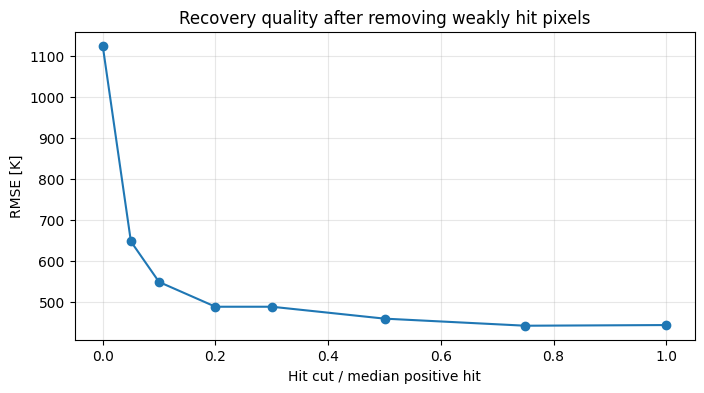

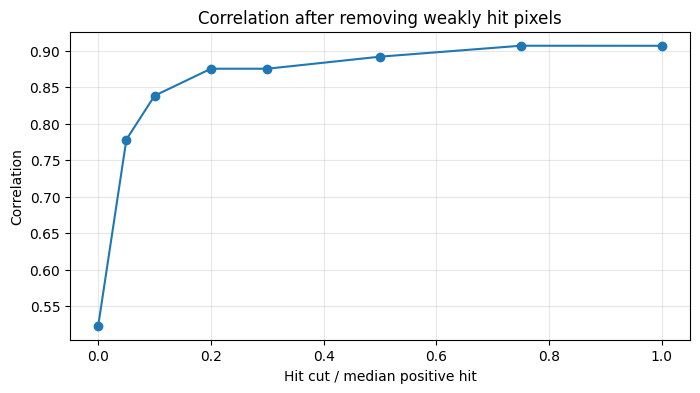

In [19]:
# ============================================================
# CELL B: metrics as a function of hit cut
# ============================================================

def metric_on_mask(rec, truth, mask):
    rec = np.asarray(rec)
    truth = np.asarray(truth)
    mask = np.asarray(mask, dtype=bool)

    if np.sum(mask) < 3:
        return {"n_pix": int(np.sum(mask)), "rmse": np.nan, "mae": np.nan, "bias": np.nan, "corr": np.nan}

    r = rec[mask]
    t = truth[mask]
    d = r - t

    corr = np.corrcoef(r, t)[0, 1] if np.std(r) > 0 and np.std(t) > 0 else np.nan

    return {
        "n_pix": int(np.sum(mask)),
        "rmse": float(np.sqrt(np.nanmean(d**2))),
        "mae": float(np.nanmean(np.abs(d))),
        "bias": float(np.nanmean(d)),
        "corr": float(corr),
    }


positive_hit = weighted_hits > 0
med_hit = np.nanmedian(weighted_hits[positive_hit])

rows = []
for frac in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]:
    cut = frac * med_hit
    mask = weighted_hits >= cut
    m = metric_on_mask(rec, truth, mask)
    m["hit_cut_fraction_of_median"] = frac
    m["hit_cut"] = cut
    rows.append(m)

hitcut_df = pd.DataFrame(rows)
display(hitcut_df)

plt.figure(figsize=(8, 4))
plt.plot(hitcut_df["hit_cut_fraction_of_median"], hitcut_df["rmse"], marker="o", label="RMSE")
plt.xlabel("Hit cut / median positive hit")
plt.ylabel("RMSE [K]")
plt.title("Recovery quality after removing weakly hit pixels")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hitcut_df["hit_cut_fraction_of_median"], hitcut_df["corr"], marker="o", label="Correlation")
plt.xlabel("Hit cut / median positive hit")
plt.ylabel("Correlation")
plt.title("Correlation after removing weakly hit pixels")
plt.grid(alpha=0.3)
plt.show()

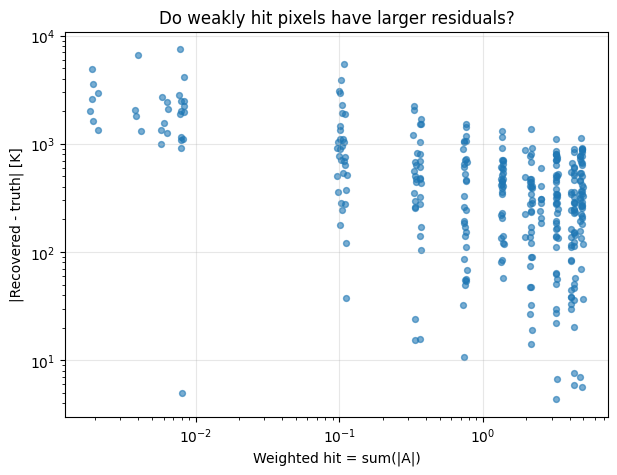

,hit_bin,n_pix,median_hit,rmse,mae,bias,corr
0,0.00184 – 0.0974,34,0.006391,2736.283422,2249.564868,-2219.642968,0.138426
1,0.0974 – 0.365,50,0.110201,1443.951363,990.715298,-902.369915,0.368897
2,0.365 – 2.12,84,0.772369,633.315301,484.800312,-114.412294,0.733365
3,2.12 – 4.07,84,3.198584,440.749974,341.072733,75.736164,0.872775
4,4.07 – 4.76,50,4.295178,369.714063,286.800560,80.584822,0.939422
5,4.76 – 4.96,34,4.882469,539.369538,453.315862,-107.534146,0.915132


In [20]:
# ============================================================
# CELL C: residual amplitude versus weighted hit
# ============================================================

mask = np.isfinite(weighted_hits) & np.isfinite(resid) & (weighted_hits > 0)

plt.figure(figsize=(7, 5))
plt.scatter(weighted_hits[mask], np.abs(resid[mask]), s=18, alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Weighted hit = sum(|A|)")
plt.ylabel("|Recovered - truth| [K]")
plt.title("Do weakly hit pixels have larger residuals?")
plt.grid(alpha=0.3)
plt.show()

# Bin residuals by hit level
bins = np.nanpercentile(weighted_hits[mask], [0, 10, 25, 50, 75, 90, 100])
bins = np.unique(bins)

bin_rows = []
for i in range(len(bins) - 1):
    lo, hi = bins[i], bins[i + 1]
    bmask = mask & (weighted_hits >= lo) & (weighted_hits <= hi if i == len(bins)-2 else weighted_hits < hi)
    if np.sum(bmask) < 3:
        continue
    mm = metric_on_mask(rec, truth, bmask)
    mm["hit_bin"] = f"{lo:.3g} – {hi:.3g}"
    mm["hit_lo"] = lo
    mm["hit_hi"] = hi
    mm["median_hit"] = float(np.nanmedian(weighted_hits[bmask]))
    bin_rows.append(mm)

hitbin_df = pd.DataFrame(bin_rows)
display(hitbin_df[["hit_bin", "n_pix", "median_hit", "rmse", "mae", "bias", "corr"]])

Strict visual mask:
  hit cut fraction: 0.3
  hit cut: 0.6356640442587397
  kept pixels: 240 / 336
  metric: {'n_pix': 240, 'rmse': 488.21973280684466, 'mae': 377.53339680276594, 'bias': 15.725932272825732, 'corr': 0.8753008291350595}


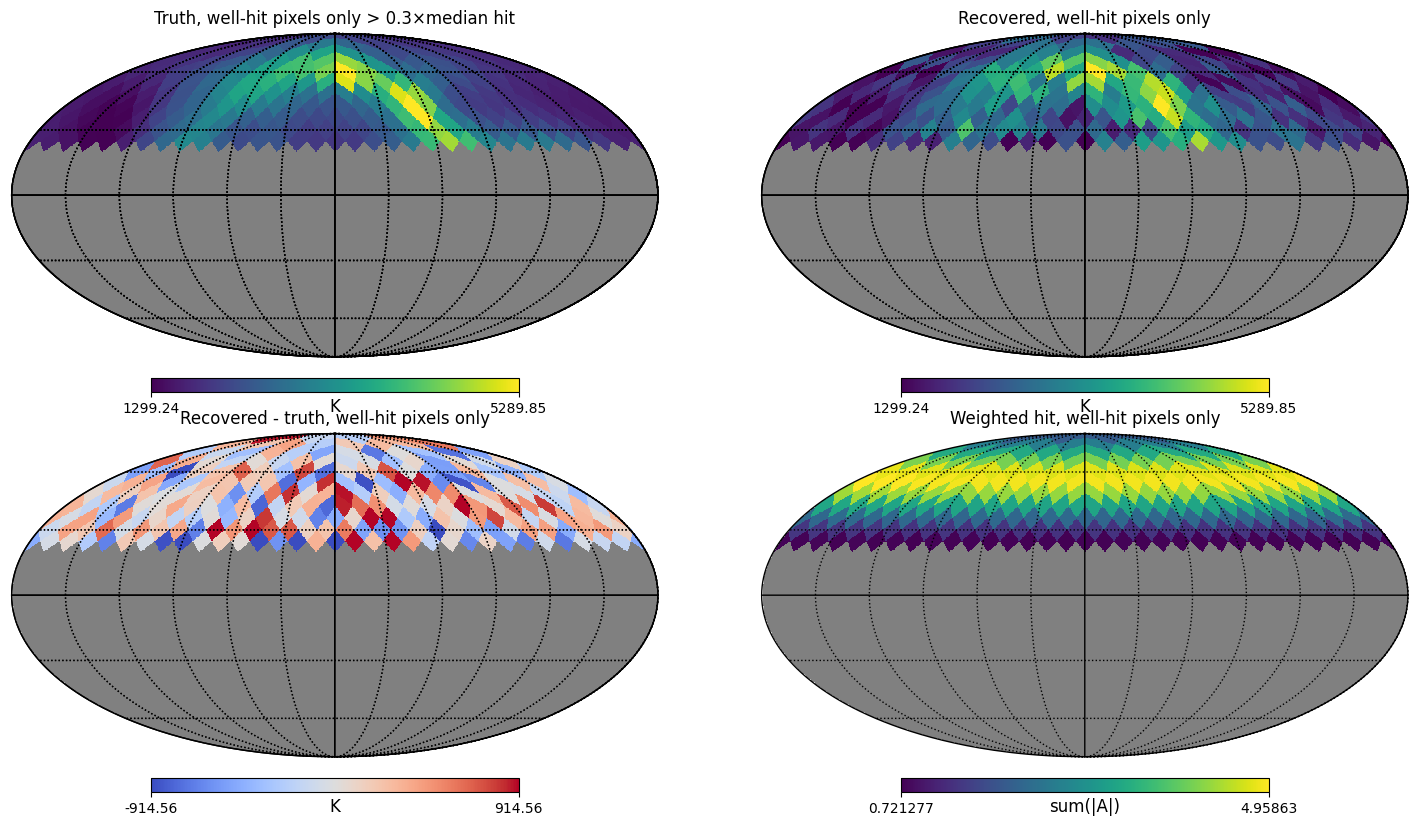

In [21]:
# ============================================================
# CELL D: plot maps after masking weakly hit pixels
# ============================================================

def patch_to_full_for_plot(values, pix, nside, mask=None):
    full = np.full(hp.nside2npix(nside), hp.UNSEEN)
    values = np.asarray(values, dtype=float).reshape(-1)

    if mask is None:
        full[pix] = values
    else:
        mask = np.asarray(mask, dtype=bool)
        full[pix[mask]] = values[mask]

    return full


MAP_NSIDE_PLOT = obs.map_nside if "obs" in globals() else hp.get_nside(reference_maps_full["plain"])

# choose strict mask for visual sanity
strict_frac = 0.3
strict_cut = strict_frac * med_hit
strict_mask = weighted_hits >= strict_cut

print("Strict visual mask:")
print("  hit cut fraction:", strict_frac)
print("  hit cut:", strict_cut)
print("  kept pixels:", np.sum(strict_mask), "/", len(strict_mask))
print("  metric:", metric_on_mask(rec, truth, strict_mask))

truth_full_strict = patch_to_full_for_plot(truth, pix, MAP_NSIDE_PLOT, strict_mask)
rec_full_strict = patch_to_full_for_plot(rec, pix, MAP_NSIDE_PLOT, strict_mask)
res_full_strict = patch_to_full_for_plot(resid, pix, MAP_NSIDE_PLOT, strict_mask)
hit_full_strict = patch_to_full_for_plot(weighted_hits, pix, MAP_NSIDE_PLOT, strict_mask)

vmin, vmax = np.nanpercentile(truth[strict_mask], [1, 99])
rmax = np.nanpercentile(np.abs(resid[strict_mask]), 95)

plt.figure(figsize=(15, 8))

hp.mollview(
    truth_full_strict,
    title=f"Truth, well-hit pixels only > {strict_frac}×median hit",
    unit="K",
    min=vmin,
    max=vmax,
    sub=(2, 2, 1),
    badcolor="gray",
)
hp.graticule()

hp.mollview(
    rec_full_strict,
    title="Recovered, well-hit pixels only",
    unit="K",
    min=vmin,
    max=vmax,
    sub=(2, 2, 2),
    badcolor="gray",
)
hp.graticule()

hp.mollview(
    res_full_strict,
    title="Recovered - truth, well-hit pixels only",
    unit="K",
    min=-rmax,
    max=rmax,
    cmap="coolwarm",
    sub=(2, 2, 3),
    badcolor="gray",
)
hp.graticule()

hp.mollview(
    hit_full_strict,
    title="Weighted hit, well-hit pixels only",
    unit="sum(|A|)",
    sub=(2, 2, 4),
    badcolor="gray",
)
hp.graticule()

plt.show()

In [22]:
# ============================================================
# CELL E: clean vs noisy residual comparison
# ============================================================

rec_clean = np.asarray(DIAG_CASE["rec_clean"], dtype=float).reshape(-1) if "rec_clean" in DIAG_CASE else None

if rec_clean is None:
    print("No rec_clean found inside DIAG_CASE. Available keys:")
    print(DIAG_CASE.keys())
else:
    resid_clean = rec_clean - truth
    resid_noisy = rec - truth
    delta_noise_effect = rec - rec_clean

    print("Clean metric, all selected pixels:", metric_on_mask(rec_clean, truth, weighted_hits > 0))
    print("Noisy metric, all selected pixels:", metric_on_mask(rec, truth, weighted_hits > 0))
    print("Noise-only map difference rec_noisy - rec_clean:")
    print("  median:", np.nanmedian(delta_noise_effect))
    print("  std:", np.nanstd(delta_noise_effect))
    print("  p5/p95:", np.nanpercentile(delta_noise_effect, [5, 95]))

    full_clean_resid = patch_to_full_for_plot(resid_clean, pix, MAP_NSIDE_PLOT)
    full_noisy_resid = patch_to_full_for_plot(resid_noisy, pix, MAP_NSIDE_PLOT)
    full_noise_effect = patch_to_full_for_plot(delta_noise_effect, pix, MAP_NSIDE_PLOT)

    rmax = np.nanpercentile(np.abs(np.concatenate([resid_clean, resid_noisy])), 95)
    nmax = np.nanpercentile(np.abs(delta_noise_effect), 95)

    plt.figure(figsize=(15, 4))

    hp.mollview(
        full_clean_resid,
        title="Clean recovery - truth",
        unit="K",
        min=-rmax,
        max=rmax,
        cmap="coolwarm",
        sub=(1, 3, 1),
        badcolor="gray",
    )
    hp.graticule()

    hp.mollview(
        full_noisy_resid,
        title=f"Noisy GLS - truth: {DIAG_NOISE_NAME}",
        unit="K",
        min=-rmax,
        max=rmax,
        cmap="coolwarm",
        sub=(1, 3, 2),
        badcolor="gray",
    )
    hp.graticule()

    hp.mollview(
        full_noise_effect,
        title="Noisy GLS - clean recovery",
        unit="K",
        min=-nmax,
        max=nmax,
        cmap="coolwarm",
        sub=(1, 3, 3),
        badcolor="gray",
    )
    hp.graticule()

    plt.show()

No rec_clean found inside DIAG_CASE. Available keys:
dict_keys(['case_key', 'scan', 'mapper', 'A', 'pix', 'hits', 'weighted_hits', 'hit_cut', 'tod_clean_direct', 'truth_patch', 'truth_plain', 'recovered_clean', 'unc_clean', 'metric_clean'])


In [23]:
# ============================================================
# CELL F: discussion-ready diagnosis table
# ============================================================

summary_rows = []

for frac in [0.0, 0.1, 0.3, 0.5]:
    cut = frac * med_hit
    mask = weighted_hits >= cut

    row = metric_on_mask(rec, truth, mask)
    row["region"] = f"hit >= {frac} × median positive hit"
    row["hit_cut"] = cut
    row["median_abs_residual_K"] = float(np.nanmedian(np.abs(resid[mask])))
    row["p90_abs_residual_K"] = float(np.nanpercentile(np.abs(resid[mask]), 90))

    if np.all(np.isfinite(unc)):
        row["median_unc_K"] = float(np.nanmedian(unc[mask]))
        row["p90_unc_K"] = float(np.nanpercentile(unc[mask], 90))

    summary_rows.append(row)

diagnosis_df = pd.DataFrame(summary_rows)
diagnosis_df = diagnosis_df[
    ["region", "n_pix", "rmse", "mae", "bias", "corr", "median_abs_residual_K", "p90_abs_residual_K"]
    + ([ "median_unc_K", "p90_unc_K"] if "median_unc_K" in diagnosis_df.columns else [])
]

display(diagnosis_df)

,region,n_pix,rmse,mae,bias,corr,median_abs_residual_K,p90_abs_residual_K,median_unc_K,p90_unc_K
0,hit >= 0.0 × median positive hit,336,1125.398291,670.080576,-367.446641,0.523040,405.297057,1523.516811,38.143802,71.009622
1,hit >= 0.1 × median positive hit,272,548.643394,410.933163,-51.555988,0.838296,323.044397,863.657965,35.115055,49.669261
2,hit >= 0.3 × median positive hit,240,488.219733,377.533397,15.725932,0.875301,302.903265,805.733875,34.027100,47.120333
3,hit >= 0.5 × median positive hit,208,459.167918,362.358865,55.340220,0.891813,302.903265,771.270164,33.169272,45.253685



Well-hit mask: hit >= 0.3 × median positive hit
kept pixels: 240 / 336
metric: {'n_pix': 240, 'rmse': 488.21973280684466, 'mae': 377.53339680276594, 'bias': 15.725932272825732, 'corr': 0.8753008291350595}


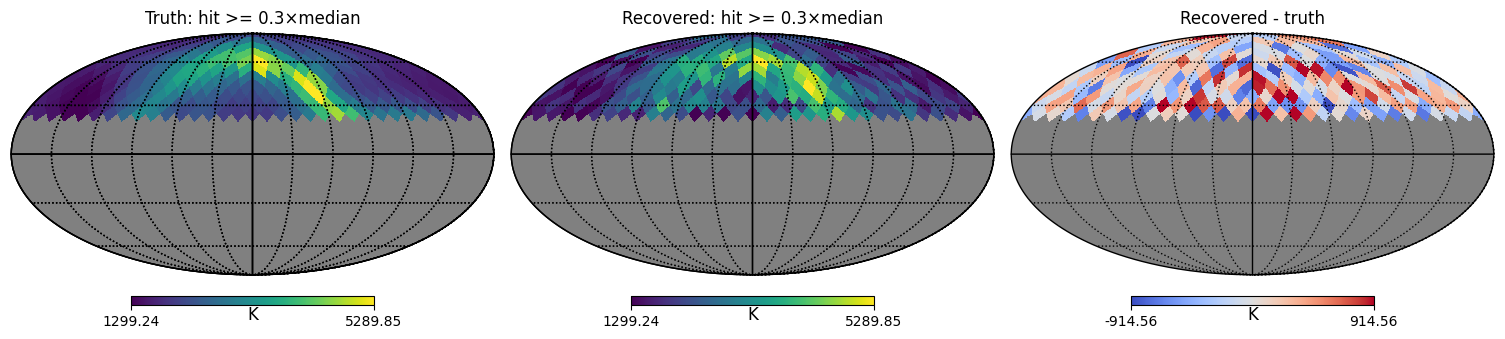


Well-hit mask: hit >= 0.5 × median positive hit
kept pixels: 208 / 336
metric: {'n_pix': 208, 'rmse': 459.16791770424794, 'mae': 362.35886456446536, 'bias': 55.340219515818376, 'corr': 0.891812663887394}


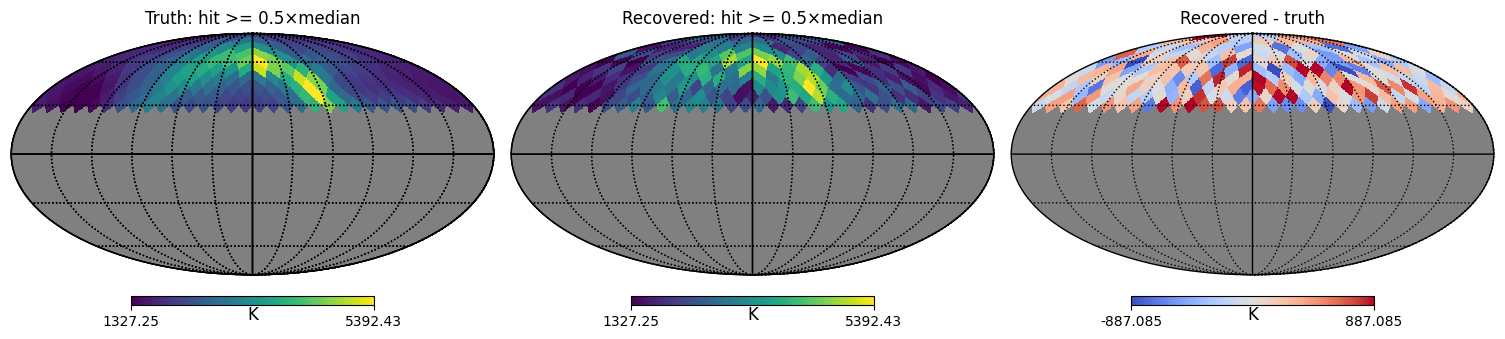


Well-hit mask: hit >= 0.75 × median positive hit
kept pixels: 176 / 336
metric: {'n_pix': 176, 'rmse': 441.86533365713285, 'mae': 345.21589622325337, 'bias': 41.65450675110066, 'corr': 0.9068268096778492}


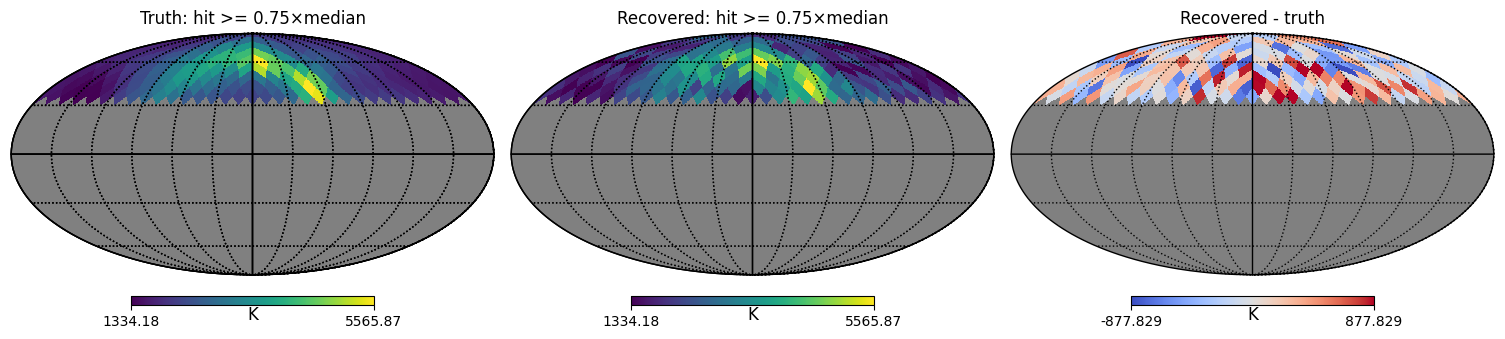


Well-hit mask: hit >= 1.0 × median positive hit
kept pixels: 168 / 336
metric: {'n_pix': 168, 'rmse': 443.49513289671154, 'mae': 347.63617169688854, 'bias': 40.08879706188439, 'corr': 0.9067408440871747}


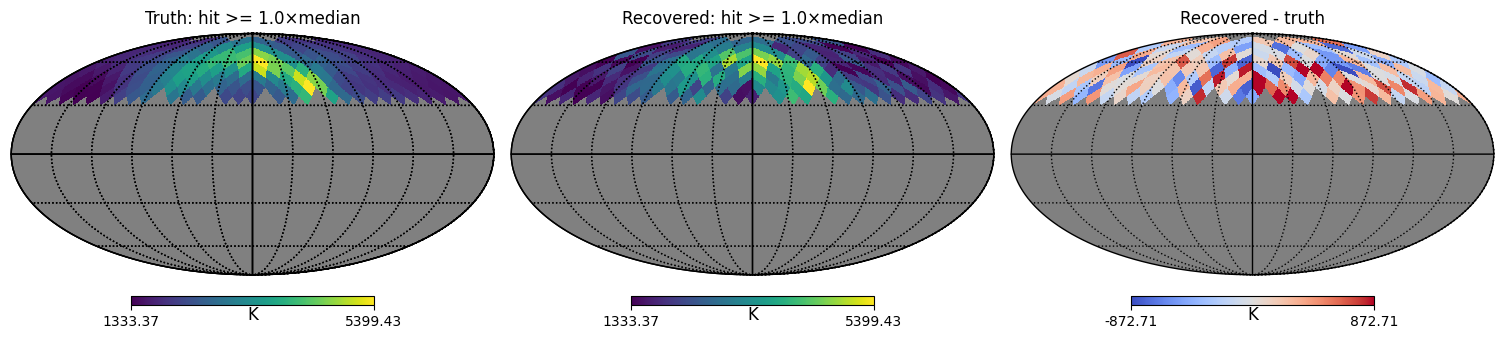

In [24]:
# ============================================================
# Try stricter well-hit masks: 0.3, 0.5, 0.75 median hit
# ============================================================

for strict_frac in [0.3, 0.5, 0.75, 1.0]:
    strict_cut = strict_frac * med_hit
    strict_mask = weighted_hits >= strict_cut

    print("\n======================================")
    print(f"Well-hit mask: hit >= {strict_frac} × median positive hit")
    print("kept pixels:", np.sum(strict_mask), "/", len(strict_mask))
    print("metric:", metric_on_mask(rec, truth, strict_mask))

    truth_full = patch_to_full_for_plot(truth, pix, MAP_NSIDE_PLOT, strict_mask)
    rec_full = patch_to_full_for_plot(rec, pix, MAP_NSIDE_PLOT, strict_mask)
    res_full = patch_to_full_for_plot(rec - truth, pix, MAP_NSIDE_PLOT, strict_mask)

    vmin, vmax = np.nanpercentile(truth[strict_mask], [1, 99])
    rmax = np.nanpercentile(np.abs((rec - truth)[strict_mask]), 95)

    plt.figure(figsize=(15, 4))

    hp.mollview(
        truth_full,
        title=f"Truth: hit >= {strict_frac}×median",
        unit="K",
        min=vmin,
        max=vmax,
        sub=(1, 3, 1),
        badcolor="gray",
    )
    hp.graticule()

    hp.mollview(
        rec_full,
        title=f"Recovered: hit >= {strict_frac}×median",
        unit="K",
        min=vmin,
        max=vmax,
        sub=(1, 3, 2),
        badcolor="gray",
    )
    hp.graticule()

    hp.mollview(
        res_full,
        title="Recovered - truth",
        unit="K",
        min=-rmax,
        max=rmax,
        cmap="coolwarm",
        sub=(1, 3, 3),
        badcolor="gray",
    )
    hp.graticule()

    plt.show()

In [25]:
# ============================================================
# Find best scan/noise case from existing summary table
# ============================================================

# Try common dataframe names from notebook
candidate_dfs = []
for name in ["scenario_noise_df", "noise_summary_df", "summary_df", "all_results_df"]:
    if name in globals():
        candidate_dfs.append((name, globals()[name]))

if not candidate_dfs:
    print("No summary dataframe found. Available global dataframes:")
    for k, v in globals().items():
        if isinstance(v, pd.DataFrame):
            print(k, v.shape, list(v.columns))
else:
    for name, df in candidate_dfs:
        print("\nDataFrame:", name)
        display(df.head())
        print("columns:", list(df.columns))


DataFrame: scenario_noise_df


,case_key,clean_label,noise_case,delta_nu_Hz,white_noise_var,sigma_frac,equiv_sigma_K_median,n_pix,rmse,bias,std,corr,median_abs_residual,p95_abs_residual
0,A_no_rotation_24h,"No rotation, 24 h",none,NaN,0.000000e+00,0.000000,0.000000,272,1160.247192,-344.109550,1108.044297,0.510276,669.899643,2504.369440
1,A_no_rotation_24h,"No rotation, 24 h",raw_10MHz_over_8192,1220.703125,6.826667e-06,0.002613,6.983750,272,1289.592190,-576.693522,1153.461138,0.516048,705.307642,2660.777116
2,A_no_rotation_24h,"No rotation, 24 h",bandavg_100kHz,100000.000000,8.333333e-08,0.000289,0.771603,272,1137.407067,-314.730100,1092.995791,0.512208,672.898794,2432.050848
3,A_no_rotation_24h,"No rotation, 24 h",bandavg_1MHz,1000000.000000,8.333333e-09,0.000091,0.244002,272,1065.361072,-132.849447,1057.045523,0.510255,651.133467,2256.617142
4,C_fast_rotation_24h_one_turn_per_hour,"Fast rotation, 24 h",none,NaN,0.000000e+00,0.000000,0.000000,272,605.594991,-80.990948,600.154780,0.809537,371.099537,1154.472718


columns: ['case_key', 'clean_label', 'noise_case', 'delta_nu_Hz', 'white_noise_var', 'sigma_frac', 'equiv_sigma_K_median', 'n_pix', 'rmse', 'bias', 'std', 'corr', 'median_abs_residual', 'p95_abs_residual']


,n_pix,rmse,mae,bias,corr,prior_sigma_K,hit_frac
0,336,1928.351425,935.310396,-3.744564,0.416626,10000,0.0
1,240,641.302956,471.352251,30.017371,0.816361,10000,0.3
2,208,588.250056,435.018175,45.359186,0.837426,10000,0.5
3,336,1919.824758,932.935310,-4.190769,0.418029,5000,0.0
4,240,640.914875,471.050086,29.968404,0.816510,5000,0.3
5,208,587.907990,434.755525,45.353529,0.837578,5000,0.5
6,336,1900.156863,927.425569,-5.190293,0.421307,3000,0.0
7,240,640.014425,470.345919,29.855725,0.816857,3000,0.3
8,208,587.115935,434.144153,45.339447,0.837929,3000,0.5
9,336,1863.768772,917.119392,-6.930738,0.427534,2000,0.0


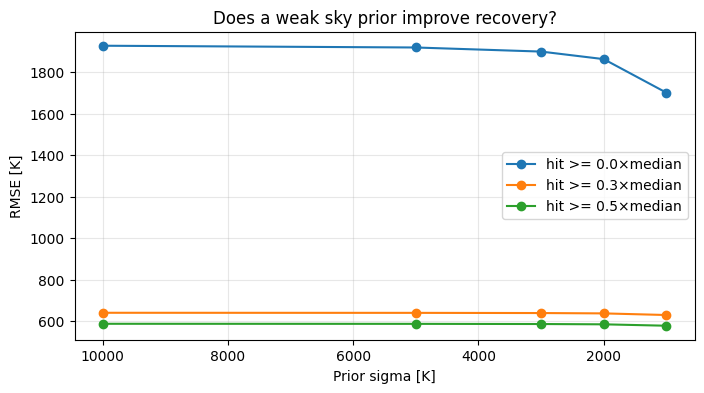

In [26]:
# ============================================================
# Optional improvement test: GLS with weak sky prior
# This does NOT replace current result; it is a comparison.
# ============================================================

def gls_with_multiplicative_noise_and_prior(
    A,
    d_noisy,
    d_clean,
    white_noise_var,
    prior_mean,
    prior_sigma_K=3000.0,
    ridge_rel=1e-8,
):
    A = np.asarray(A, dtype=float)
    d_noisy = np.asarray(d_noisy, dtype=float).reshape(-1)
    d_clean = np.asarray(d_clean, dtype=float).reshape(-1)
    prior_mean = np.asarray(prior_mean, dtype=float).reshape(-1)

    var_t = white_noise_var * d_clean**2
    good = np.isfinite(var_t) & (var_t > 0)
    floor = 1e-8 * np.nanmedian(var_t[good])
    var_t = np.maximum(var_t, floor)

    w = 1.0 / var_t

    lhs_data = A.T @ (A * w[:, None])
    rhs_data = A.T @ (w * d_noisy)

    prior_inv = 1.0 / prior_sigma_K**2

    diag_scale = np.nanmedian(np.diag(lhs_data))
    ridge = ridge_rel * diag_scale

    lhs = lhs_data + (prior_inv + ridge) * np.eye(A.shape[1])
    rhs = rhs_data + prior_inv * prior_mean

    rec_prior = np.linalg.solve(lhs, rhs)
    unc_prior = np.sqrt(np.clip(np.diag(np.linalg.inv(lhs)), 0, np.inf))

    return rec_prior, unc_prior


# Get A and noisy TOD pieces from the current diagnostic case
A_diag = np.asarray(DIAG_CASE["A"], dtype=float)
sim = diag_pack["sim"]

d_noisy = np.asarray(sim["tod_noisy"], dtype=float).reshape(-1)
d_clean = np.asarray(sim["tod_clean"], dtype=float).reshape(-1)
white_noise_var = float(sim["white_noise_var"])

prior_rows = []
prior_results = {}

for prior_sigma in [10000, 5000, 3000, 2000, 1000]:
    rec_p, unc_p = gls_with_multiplicative_noise_and_prior(
        A=A_diag,
        d_noisy=d_noisy,
        d_clean=d_clean,
        white_noise_var=white_noise_var,
        prior_mean=truth,          # simulation sanity prior
        prior_sigma_K=prior_sigma,
        ridge_rel=1e-8,
    )

    prior_results[prior_sigma] = {
        "rec": rec_p,
        "unc": unc_p,
        "resid": rec_p - truth,
    }

    for frac in [0.0, 0.3, 0.5]:
        mask = weighted_hits >= frac * med_hit
        m = metric_on_mask(rec_p, truth, mask)
        m["prior_sigma_K"] = prior_sigma
        m["hit_frac"] = frac
        prior_rows.append(m)

prior_df = pd.DataFrame(prior_rows)
display(prior_df)

plt.figure(figsize=(8, 4))
for frac in [0.0, 0.3, 0.5]:
    sub = prior_df[prior_df["hit_frac"] == frac]
    plt.plot(sub["prior_sigma_K"], sub["rmse"], marker="o", label=f"hit >= {frac}×median")
plt.gca().invert_xaxis()
plt.xlabel("Prior sigma [K]")
plt.ylabel("RMSE [K]")
plt.title("Does a weak sky prior improve recovery?")
plt.legend()
plt.grid(alpha=0.3)
plt.show()